# Краткое описание того что сделано, и в чём проблемы

Что было сделано до этого файла:
1) Все данные были приведены к кодам ОКВЭД2 с 3 знаками.
2) Данные собраны в панель ниже.

Что было сделано в этом файле и проблемы:
1) Построены регрессии интенсивности, рассчитаны как логарифм суммы контрактов на выпуск. Тут проблема, что выпуск есть только по обрабатывающим производствам. Таким образом, существено сужается итоговый датасет. Не ясно что с этим делать.
2) Подготовлен фрейм для аналогичного анализа с разбивкой по макроотраслям: обрабатывающая, сырьевая промышленность и услуги. Проблема такая же как и в п. 1.
3) Подготовлен Event-study. С ним проблем нет
4) Подготовлены регрессии числа заказчиков и поставщиков. Нет регрессии для покупателей 223-ФЗ, потому что нет данных.
5) Дополнительная проверка межотраслевой гетерогенности. Отобраны несколько самых крупных по сумме конрактов на уровне двух знаков и построены регресии интенсивности.
6) Рассмотрены альтернативные спецификации в рамках проверки устойчивости.



# Библиотеки и настройки

In [827]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS
from stargazer.stargazer import Stargazer
import os
import numpy as np

# Регрессии интенсивности

In [828]:
# Настройка визуализации
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Создание папки для результатов, если её нет
os.makedirs('results', exist_ok=True)
os.makedirs('results/tables', exist_ok=True)
os.makedirs('results/figures', exist_ok=True)

## Подготовка данных

In [829]:
# Загрузка и базовая инфа
base_panel = pd.read_excel('панель.xlsx')
panel_df = base_panel.copy()

print(f"Размер панели: {panel_df.shape[0]} наблюдений, {panel_df.shape[1]} переменных")
print(f"Временной период: {panel_df['year'].min()} – {panel_df['year'].max()}")
print(f"Количество отраслей (OKVED_3): {panel_df['OKVED_3'].nunique()}")
print("\nПервые 5 строк:")
panel_df.head()

Размер панели: 1270 наблюдений, 12 переменных
Временной период: 2016 – 2025
Количество отраслей (OKVED_3): 127

Первые 5 строк:


,OKVED_3,year,customers44_count,customers223_count,suppliers44_count,suppliers223_count,contracts44_count,contracts44_sum,contracts223_count,contracts223_sum,output,sanction_share
0,1.1,2016,5088.000000,733.666667,1804.000000,2974.0,19564.000000,1.387054e+10,3105.000000,5.599679e+10,0.0,0.0
1,1.1,2017,5016.000000,575.666667,1749.333333,2712.0,18810.333333,1.466740e+10,2864.666667,3.444748e+10,0.0,0.0
2,1.1,2018,4779.000000,651.000000,1607.666667,1388.0,18103.333333,1.429202e+10,3014.000000,3.995172e+10,0.0,0.0
3,1.1,2019,4491.000000,815.333333,1316.000000,0.0,15523.000000,1.492627e+10,3929.666667,4.931383e+10,0.0,0.0
4,1.1,2020,3930.333333,775.333333,1095.333333,0.0,10468.000000,1.002316e+10,3417.666667,3.613539e+10,0.0,0.0


In [830]:
# Удаление строк с пропусками в ключевых переменных
panel_df = panel_df.dropna(subset=['OKVED_3', 'year', 'contracts44_sum', 'contracts223_sum', 'output'])
panel_df = panel_df[panel_df['year'] != 2025]

print(f"\nПосле очистки пропусков и 2025 года: {panel_df.shape[0]} наблюдений")


После очистки пропусков и 2025 года: 1143 наблюдений


### Создание переменных интенсивности

In [831]:
# Интенсивность 44-ФЗ = log(contracts44sum / output)
# Эта переменная показывает долю госзаказа по контрактной системе в общем выпуске
panel_df['intensity_44'] = np.log(panel_df['contracts44_sum'] / panel_df['output'])

# Интенсивность 223-ФЗ = log(contracts223sum / output)
# Эта переменная показывает долю корпоративных закупок в общем выпуске
panel_df['intensity_223'] = np.log(panel_df['contracts223_sum'] / panel_df['output'])

# Общая интенсивность
panel_df['intensity_total'] = np.log((panel_df['contracts44_sum'] + panel_df['contracts223_sum']) / panel_df['output'])

# Логарифм выпуска (для использования как контроль в моделях)
panel_df['log_output'] = np.log(panel_df['output'])

# Лаг санкционной переменной (t-1)
panel_df['sanction_lag1'] = panel_df.groupby('OKVED_3')['sanction_share'].shift(1)

# Проверка: нет ли бесконечности в логарифмах
print(f"Бесконечные значения в intensity_44: {np.isinf(panel_df['intensity_44']).sum()}")
print(f"Бесконечные значения в intensity_223: {np.isinf(panel_df['intensity_223']).sum()}")

# Удаление строк с бесконечностью
panel_df = panel_df.replace([np.inf, -np.inf], np.nan)
panel_df = panel_df.dropna(subset=['intensity_44', 'intensity_223', 'intensity_total'])

print(f"После удаления -inf/+inf: {panel_df.shape[0]} наблюдений")

# Описательная статистика по интенсивностям
print("\nОписательная статистика интенсивностей:")
panel_df[['intensity_44', 'intensity_223', 'intensity_total', 'sanction_share']].describe()

Бесконечные значения в intensity_44: 839
Бесконечные значения в intensity_223: 839
После удаления -inf/+inf: 304 наблюдений

Описательная статистика интенсивностей:


,intensity_44,intensity_223,intensity_total,sanction_share
count,304.000000,304.000000,304.000000,304.000000
mean,4.023464,4.804816,5.303486,0.022599
std,1.992521,1.810882,1.820505,0.047387
min,0.553294,1.353153,2.162622,0.000000
25%,2.470783,3.466218,3.835212,0.000000
50%,3.674329,4.648846,5.172121,0.000000
75%,5.209819,6.012413,6.492684,0.021426
max,9.354967,9.405233,9.915237,0.294290


### Создание макрогрупп

In [832]:
def extract_okved2_prefix(code):
    """
    Извлекает первые две цифры из кода ОКВЭД2
    Пример: '10.11.1' -> '10'
    """
    try:
        return int(str(code).split('.')[0])
    except:
        return np.nan

In [833]:
def classify_macro_industry(okved2_code):
    """
    Классифицирует отрасли ОКВЭД2 в три макроблока:
    - Raw (сырьевые): 01-09 (сельское хозяйство, рыбное хозяйство, добыча)
    - Manufacturing (обрабатывающие): 10-33 (производство)
    - Services (услуги): 35-82 (энергетика, водоснабжение, строительство, услуги)
    """
    if pd.isna(okved2_code):
        return 'Unknown'
    
    code_int = int(okved2_code)
    
    if 1 <= code_int <= 9:
        return 'Raw'
    elif 10 <= code_int <= 33:
        return 'Manufacturing'
    elif 35 <= code_int <= 82:
        return 'Services'
    else:
        return 'Unknown'

#### ПРОБЛЕМА!

In [834]:
"""
!!!
ТУТ ПРОБЛЕМА С OUTPUT. ОНА СУЩЕСТВУЕТ ТОЛЬКО ДЛЯ ОТРАСЛЕЙ ОБРАБАТЫВАЮЩЕЙ ПРОМЫШЛЕННОСТИ.
ДЛЯ ОСТАЛЬНЫХ ОНА РАВНА НУЛЮ. ПРИ ЛОГАРИФМИРОВАНИИ ПОЯВЛЯЮТСЯ БЕСКОНЕЧНОСТИ, КОТОРЫЕ СКРИПТ ВЫКИДЫВАЕТ
НАДО РЕШИТЬ ЭТУ ПРОБЛЕМУ В БУДУЩЕМ
!!!
"""

# Применяем функции к данным
panel_df['okved2_prefix'] = panel_df['OKVED_3'].apply(extract_okved2_prefix)
panel_df['macro_industry'] = panel_df['okved2_prefix'].apply(classify_macro_industry)

# Проверка распределения по макроотраслям
print("\nРаспределение отраслей по макрогруппам:")
print(panel_df['macro_industry'].value_counts())


Распределение отраслей по макрогруппам:
macro_industry
Manufacturing    304
Name: count, dtype: int64


### Сохраняем копию panel_df с мультииндексом

In [835]:
# Создаём копию с мультииндексом
panel_full = panel_df.copy()
panel_full = panel_full.set_index(['OKVED_3', 'year'])

# Сохраняем также версии для макроотраслевого анализа
panel_raw = panel_df[panel_df['macro_industry'] == 'Raw'].copy()
panel_raw = panel_raw.set_index(['OKVED_3', 'year'])

panel_manuf = panel_df[panel_df['macro_industry'] == 'Manufacturing'].copy()
panel_manuf = panel_manuf.set_index(['OKVED_3', 'year'])

panel_serv = panel_df[panel_df['macro_industry'] == 'Services'].copy()
panel_serv = panel_serv.set_index(['OKVED_3', 'year'])

print(f"Размеры панелей:")
print(f"  - Полная панель: {panel_full.shape[0]}")
print(f"  - Сырьевые: {panel_raw.shape[0]}")
print(f"  - Обрабатывающие: {panel_manuf.shape[0]}")
print(f"  - Услуги: {panel_serv.shape[0]}")

Размеры панелей:
  - Полная панель: 304
  - Сырьевые: 0
  - Обрабатывающие: 304
  - Услуги: 0


## Базовые модели

In [836]:
# Словарь для хранения результатов
results_dict = {}

### 44-ФЗ

In [837]:
# Модель 1: intensity_44 ~ sanction_share (без контролей)
print("\nМодель 1: intensity_44 ~ sanction_share + FE(отрасль, год)")
model_1 = PanelOLS(
    panel_full['intensity_44'],
    panel_full[['sanction_share']],
    entity_effects=True,
    time_effects=True
)
res_1 = model_1.fit(cov_type='clustered', cluster_entity=True)
results_dict['int44_basic'] = res_1
res_1.summary


Модель 1: intensity_44 ~ sanction_share + FE(отрасль, год)


Dep. Variable:,intensity_44,R-squared:,0.0008
Estimator:,PanelOLS,R-squared (Between):,-0.0025
No. Observations:,304,R-squared (Within):,0.0249
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-0.0023
Time:,18:32:07,Log-likelihood,-4.3578
Cov. Estimator:,Clustered,,
,,F-statistic:,0.1938
Entities:,38,P-value,0.6601
Avg Obs:,8.0000,Distribution:,"F(1,258)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,0.0497


In [838]:
# Модель 2: intensity_44 ~ sanction_share + log_output (с контролем выпуска)
print("\nМодель 2: intensity_44 ~ sanction_share + log_output + FE")
model_2 = PanelOLS(
    panel_full['intensity_44'],
    panel_full[['sanction_share', 'log_output']],
    entity_effects=True,
    time_effects=True
)
res_2 = model_2.fit(cov_type='clustered', cluster_entity=True)
results_dict['int44_with_output'] = res_2
res_2.summary


Модель 2: intensity_44 ~ sanction_share + log_output + FE


Dep. Variable:,intensity_44,R-squared:,0.3622
Estimator:,PanelOLS,R-squared (Between):,-25.122
No. Observations:,304,R-squared (Within):,0.5327
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-24.987
Time:,18:32:07,Log-likelihood,63.891
Cov. Estimator:,Clustered,,
,,F-statistic:,72.979
Entities:,38,P-value,0.0000
Avg Obs:,8.0000,Distribution:,"F(2,257)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,37.887


In [839]:
# Модель 3: intensity_44 ~ sanction_lag1 (с лагом)
# Для этой модели нужно удалить первый год в панели (где нет лага)
panel_full_lag = panel_full[panel_full.index.get_level_values('year') > panel_full.index.get_level_values('year').min()]

print("\nМодель 3: intensity_44 ~ sanction_lag1 + FE")
model_3 = PanelOLS(
    panel_full_lag['intensity_44'],
    panel_full_lag[['sanction_lag1']],
    entity_effects=True,
    time_effects=True
)
res_3 = model_3.fit(cov_type='clustered', cluster_entity=True)
results_dict['int44_lag'] = res_3
res_3.summary


Модель 3: intensity_44 ~ sanction_lag1 + FE


Dep. Variable:,intensity_44,R-squared:,0.0023
Estimator:,PanelOLS,R-squared (Between):,-0.0030
No. Observations:,266,R-squared (Within):,0.0283
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-0.0029
Time:,18:32:07,Log-likelihood,12.815
Cov. Estimator:,Clustered,,
,,F-statistic:,0.5057
Entities:,38,P-value,0.4778
Avg Obs:,7.0000,Distribution:,"F(1,221)"
Min Obs:,7.0000,,
Max Obs:,7.0000,F-statistic (robust):,0.0945


In [840]:
# Модель 4: intensity_44 ~ sanction_lag1 + log_output (с лагом и контролем)
print("\nМодель 4: intensity_44 ~ sanction_lag1 + log_output + FE")
model_4 = PanelOLS(
    panel_full_lag['intensity_44'],
    panel_full_lag[['sanction_lag1', 'log_output']],
    entity_effects=True,
    time_effects=True
)
res_4 = model_4.fit(cov_type='clustered', cluster_entity=True)
results_dict['int44_lag_output'] = res_4
res_4.summary


Модель 4: intensity_44 ~ sanction_lag1 + log_output + FE


Dep. Variable:,intensity_44,R-squared:,0.3929
Estimator:,PanelOLS,R-squared (Between):,-25.749
No. Observations:,266,R-squared (Within):,0.5853
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-25.619
Time:,18:32:07,Log-likelihood,78.892
Cov. Estimator:,Clustered,,
,,F-statistic:,71.197
Entities:,38,P-value,0.0000
Avg Obs:,7.0000,Distribution:,"F(2,220)"
Min Obs:,7.0000,,
Max Obs:,7.0000,F-statistic (robust):,23.619


### 223-ФЗ

In [841]:
# Модель 5: intensity_223 ~ sanction_share
print("\nМодель 5: intensity_223 ~ sanction_share + FE")
model_5 = PanelOLS(
    panel_full['intensity_223'],
    panel_full[['sanction_share']],
    entity_effects=True,
    time_effects=True
)
res_5 = model_5.fit(cov_type='clustered', cluster_entity=True)
results_dict['int223_basic'] = res_5
res_5.summary


Модель 5: intensity_223 ~ sanction_share + FE


Dep. Variable:,intensity_223,R-squared:,0.0536
Estimator:,PanelOLS,R-squared (Between):,-0.0280
No. Observations:,304,R-squared (Within):,0.2133
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-0.0261
Time:,18:32:07,Log-likelihood,-108.96
Cov. Estimator:,Clustered,,
,,F-statistic:,14.621
Entities:,38,P-value,0.0002
Avg Obs:,8.0000,Distribution:,"F(1,258)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,1.9914


In [842]:
# Модель 6: intensity_223 ~ sanction_share + log_output
print("\nМодель 6: intensity_223 ~ sanction_share + log_output + FE")
model_6 = PanelOLS(
    panel_full['intensity_223'],
    panel_full[['sanction_share', 'log_output']],
    entity_effects=True,
    time_effects=True
)
res_6 = model_6.fit(cov_type='clustered', cluster_entity=True)
results_dict['int223_with_output'] = res_6
res_6.summary


Модель 6: intensity_223 ~ sanction_share + log_output + FE


Dep. Variable:,intensity_223,R-squared:,0.1187
Estimator:,PanelOLS,R-squared (Between):,-9.3803
No. Observations:,304,R-squared (Within):,0.3247
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-9.3045
Time:,18:32:07,Log-likelihood,-98.133
Cov. Estimator:,Clustered,,
,,F-statistic:,17.310
Entities:,38,P-value,0.0000
Avg Obs:,8.0000,Distribution:,"F(2,257)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,2.7642


In [843]:
# Модель 7: intensity_223 ~ sanction_lag1
print("\nМодель 7: intensity_223 ~ sanction_lag1 + FE")
model_7 = PanelOLS(
    panel_full_lag['intensity_223'],
    panel_full_lag[['sanction_lag1']],
    entity_effects=True,
    time_effects=True
)
res_7 = model_7.fit(cov_type='clustered', cluster_entity=True)
results_dict['int223_lag'] = res_7
res_7.summary


Модель 7: intensity_223 ~ sanction_lag1 + FE


Dep. Variable:,intensity_223,R-squared:,0.0081
Estimator:,PanelOLS,R-squared (Between):,-0.0079
No. Observations:,266,R-squared (Within):,0.0645
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-0.0073
Time:,18:32:07,Log-likelihood,-107.23
Cov. Estimator:,Clustered,,
,,F-statistic:,1.8034
Entities:,38,P-value,0.1807
Avg Obs:,7.0000,Distribution:,"F(1,221)"
Min Obs:,7.0000,,
Max Obs:,7.0000,F-statistic (robust):,0.3425


In [844]:
# Модель 8: intensity_223 ~ sanction_lag1 + log_output
print("\nМодель 8: intensity_223 ~ sanction_lag1 + log_output + FE")
model_8 = PanelOLS(
    panel_full_lag['intensity_223'],
    panel_full_lag[['sanction_lag1', 'log_output']],
    entity_effects=True,
    time_effects=True
)
res_8 = model_8.fit(cov_type='clustered', cluster_entity=True)
results_dict['int223_lag_output'] = res_8
res_8.summary


Модель 8: intensity_223 ~ sanction_lag1 + log_output + FE


Dep. Variable:,intensity_223,R-squared:,0.0602
Estimator:,PanelOLS,R-squared (Between):,-8.5522
No. Observations:,266,R-squared (Within):,0.3046
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-8.4775
Time:,18:32:07,Log-likelihood,-100.05
Cov. Estimator:,Clustered,,
,,F-statistic:,7.0461
Entities:,38,P-value,0.0011
Avg Obs:,7.0000,Distribution:,"F(2,220)"
Min Obs:,7.0000,,
Max Obs:,7.0000,F-statistic (robust):,0.9809


## Модели макрогрупп

In [845]:
# Чтобы не дублировать код, создаём функцию оценки моделей дял каждой макроотрасли
def estimate_macro_models(panel_data, macro_name, results_dict):
    """
    Оценивает 4 базовые спецификации для определённой макроотрасли
    """
    print(f"\n--- Макроотрасль: {macro_name} (N={panel_data.shape[0]}) ---")
    
    # Модель 44-ФЗ без контролей
    m1 = PanelOLS(
        panel_data['intensity_44'],
        panel_data[['sanction_share']],
        entity_effects=True,
        time_effects=True
    )
    r1 = m1.fit(cov_type='clustered', cluster_entity=True)
    results_dict[f'int44_{macro_name}_basic'] = r1
    print(f"\nint44 ~ sanction (в {macro_name}): coef = {r1.params[0]:.4f}, p-value = {r1.pvalues[0]:.4f}")
    
    # Модель 44-ФЗ с контролем
    m2 = PanelOLS(
        panel_data['intensity_44'],
        panel_data[['sanction_share', 'log_output']],
        entity_effects=True,
        time_effects=True
    )
    r2 = m2.fit(cov_type='clustered', cluster_entity=True)
    results_dict[f'int44_{macro_name}_output'] = r2
    print(f"int44 ~ sanction, log_output (в {macro_name}): coef = {r2.params[0]:.4f}, p-value = {r2.pvalues[0]:.4f}")

    # Модель 223-ФЗ без контролей
    m3 = PanelOLS(
        panel_data['intensity_223'],
        panel_data[['sanction_share']],
        entity_effects=True,
        time_effects=True
    )
    r3 = m3.fit(cov_type='clustered', cluster_entity=True)
    results_dict[f'int223_{macro_name}_basic'] = r3
    print(f"int223 ~ sanction (в {macro_name}): coef = {r3.params[0]:.4f}, p-value = {r3.pvalues[0]:.4f}")
    
    # Модель 223-ФЗ с контролем
    m4 = PanelOLS(
        panel_data['intensity_223'],
        panel_data[['sanction_share', 'log_output']],
        entity_effects=True,
        time_effects=True
    )
    r4 = m4.fit(cov_type='clustered', cluster_entity=True)
    results_dict[f'int223_{macro_name}_output'] = r4
    print(f"int223 ~ sanction, log_output (в {macro_name}): coef = {r4.params[0]:.4f}, p-value = {r4.pvalues[0]:.4f}")

    return results_dict

In [846]:
# Оцениваем модели для каждой макроотрасли
# results_dict = estimate_macro_models(panel_raw, 'Raw', results_dict)
results_dict = estimate_macro_models(panel_manuf, 'Manufacturing', results_dict)
# results_dict = estimate_macro_models(panel_serv, 'Services', results_dict)


--- Макроотрасль: Manufacturing (N=304) ---

int44 ~ sanction (в Manufacturing): coef = -0.2380, p-value = 0.8238
int44 ~ sanction, log_output (в Manufacturing): coef = -0.8152, p-value = 0.0936
int223 ~ sanction (в Manufacturing): coef = -2.9162, p-value = 0.1594
int223 ~ sanction, log_output (в Manufacturing): coef = -3.2712, p-value = 0.0684


## Event-study

In [847]:
# Создание бинарных переменных для каждого года после 2021
panel_full['event_2022'] = (panel_full.index.get_level_values('year') == 2022).astype(int)
panel_full['event_2023'] = (panel_full.index.get_level_values('year') == 2023).astype(int)
panel_full['event_2024'] = (panel_full.index.get_level_values('year') == 2024).astype(int)

# Для правильной event-study создадим переменные, взвешенные на sanction_share
panel_full['event_sanc_2022'] = panel_full['sanction_share'] * panel_full['event_2022']
panel_full['event_sanc_2023'] = panel_full['sanction_share'] * panel_full['event_2023']
panel_full['event_sanc_2024'] = panel_full['sanction_share'] * panel_full['event_2024']

### 44-ФЗ

In [848]:
# Event-study: intensity_44 ~ event_sanc_2022 + event_sanc_2023 + event_sanc_2024 + FE
model_es_1 = PanelOLS(
    panel_full['intensity_44'],
    panel_full[['event_sanc_2022', 'event_sanc_2023', 'event_sanc_2024']],
    entity_effects=True,
    time_effects=True
)
res_es_1 = model_es_1.fit(cov_type='clustered', cluster_entity=True)
results_dict['int44_event'] = res_es_1
res_es_1.summary

Dep. Variable:,intensity_44,R-squared:,0.0044
Estimator:,PanelOLS,R-squared (Between):,-0.0026
No. Observations:,304,R-squared (Within):,0.0320
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-0.0024
Time:,18:32:07,Log-likelihood,-3.8028
Cov. Estimator:,Clustered,,
,,F-statistic:,0.3765
Entities:,38,P-value,0.7700
Avg Obs:,8.0000,Distribution:,"F(3,256)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,1.7362


In [849]:
# Event-study с контролем: intensity_44 ~ event_sanc_2022 + event_sanc_2023 + event_sanc_2024 + log_output + FE
model_es_2 = PanelOLS(
    panel_full['intensity_44'],
    panel_full[['event_sanc_2022', 'event_sanc_2023', 'event_sanc_2024', 'log_output']],
    entity_effects=True,
    time_effects=True
)
res_es_2 = model_es_2.fit(cov_type='clustered', cluster_entity=True)
results_dict['int44_event_output'] = res_es_2
res_es_2.summary

Dep. Variable:,intensity_44,R-squared:,0.3642
Estimator:,PanelOLS,R-squared (Between):,-25.138
No. Observations:,304,R-squared (Within):,0.5247
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-25.003
Time:,18:32:07,Log-likelihood,64.366
Cov. Estimator:,Clustered,,
,,F-statistic:,36.519
Entities:,38,P-value,0.0000
Avg Obs:,8.0000,Distribution:,"F(4,255)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,35.519


### 223-ФЗ

In [850]:
# Event-study: intensity_223 ~ event_sanc_2022 + event_sanc_2023 + event_sanc_2024 + FE
model_es_3 = PanelOLS(
    panel_full['intensity_223'],
    panel_full[['event_sanc_2022', 'event_sanc_2023', 'event_sanc_2024']],
    entity_effects=True,
    time_effects=True
)
res_es_3 = model_es_3.fit(cov_type='clustered', cluster_entity=True)
results_dict['int223_event'] = res_es_3
res_es_3.summary

Dep. Variable:,intensity_223,R-squared:,0.0588
Estimator:,PanelOLS,R-squared (Between):,-0.0284
No. Observations:,304,R-squared (Within):,0.2100
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-0.0265
Time:,18:32:07,Log-likelihood,-108.12
Cov. Estimator:,Clustered,,
,,F-statistic:,5.3345
Entities:,38,P-value,0.0014
Avg Obs:,8.0000,Distribution:,"F(3,256)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,10.217


In [851]:
# Event-study с контролем: intensity_223 ~ event_sanc_2022 + event_sanc_2023 + event_sanc_2024 + log_output + FE
model_es_4 = PanelOLS(
    panel_full['intensity_223'],
    panel_full[['event_sanc_2022', 'event_sanc_2023', 'event_sanc_2024', 'log_output']],
    entity_effects=True,
    time_effects=True
)
res_es_4 = model_es_4.fit(cov_type='clustered', cluster_entity=True)
results_dict['int223_event_output'] = res_es_4
res_es_4.summary

Dep. Variable:,intensity_223,R-squared:,0.1223
Estimator:,PanelOLS,R-squared (Between):,-9.2369
No. Observations:,304,R-squared (Within):,0.3184
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-9.1624
Time:,18:32:07,Log-likelihood,-97.515
Cov. Estimator:,Clustered,,
,,F-statistic:,8.8820
Entities:,38,P-value,0.0000
Avg Obs:,8.0000,Distribution:,"F(4,255)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,9.3063


## Создание таблиц с помощью Stargazer

In [852]:
# Таблица 1: Основные результаты по intensity_44
stargazer_1 = Stargazer(
    [results_dict['int44_basic'], results_dict['int44_with_output'], 
     results_dict['int44_lag'], results_dict['int44_lag_output']]
)
stargazer_1.title("Анализ интенсивности 44-ФЗ: Влияние санкций")
stargazer_1.custom_columns(['Без контролей', 'С log_output', 'С лагом', 'С лагом + output'], [1, 1, 1, 1])
stargazer_1.dependent_variable_name("log(Contracts44 / Output)")
stargazer_1.covariate_order(['sanction_share', 'sanction_lag1', 'log_output'])
stargazer_1.rename_covariates(
    {'sanction_share': 'Санкционная нагрузка', 
     'sanction_lag1': 'Санкционная нагрузка (t-1)',
     'log_output': 'log(Выпуск)'}
)
stargazer_1.show_confidence_intervals(False)
stargazer_1.significant_digits(3)

html_1 = stargazer_1.render_html()
with open('results/tables/intensity_44_main.html', 'w', encoding='utf-8') as f:
    f.write(html_1)
print("Таблица интенсивности 44-ФЗ сохранена!")

# Таблица 2: Основные результаты по intensity_223
stargazer_2 = Stargazer(
    [results_dict['int223_basic'], results_dict['int223_with_output'], 
     results_dict['int223_lag'], results_dict['int223_lag_output']]
)
stargazer_2.title("Анализ интенсивности 223-ФЗ: Влияние санкций")
stargazer_2.custom_columns(['Без контролей', 'С log_output', 'С лагом', 'С лагом + output'], [1, 1, 1, 1])
stargazer_2.dependent_variable_name("log(Contracts223 / Output)")
stargazer_2.covariate_order(['sanction_share', 'sanction_lag1', 'log_output'])
stargazer_2.rename_covariates(
    {'sanction_share': 'Санкционная нагрузка', 
     'sanction_lag1': 'Санкционная нагрузка (t-1)',
     'log_output': 'log(Выпуск)'}
)
stargazer_2.show_confidence_intervals(False)
stargazer_2.significant_digits(3)

html_2 = stargazer_2.render_html()
with open('results/tables/intensity_223_main.html', 'w', encoding='utf-8') as f:
    f.write(html_2)
print("Таблица интенсивности 223-ФЗ сохранена!")

# Таблица 3: Event-study по интенсивности
stargazer_3 = Stargazer(
    [results_dict['int44_event'], results_dict['int44_event_output'],
     results_dict['int223_event'], results_dict['int223_event_output']]
)
stargazer_3.title("Event-study: Динамика эффекта санкций на интенсивность закупок")
stargazer_3.custom_columns(['44-ФЗ', '44-ФЗ +output', '223-ФЗ', '223-ФЗ +output'], [1, 1, 1, 1])
stargazer_3.covariate_order(['event_sanc_2022', 'event_sanc_2023', 'event_sanc_2024', 'log_output'])
stargazer_3.rename_covariates(
    {'event_sanc_2022': 'Санкции × 2022',
     'event_sanc_2023': 'Санкции × 2023',
     'event_sanc_2024': 'Санкции × 2024',
     'log_output': 'log(Выпуск)'}
)
stargazer_3.show_confidence_intervals(False)
stargazer_3.significant_digits(3)

html_3 = stargazer_3.render_html()
with open('results/tables/intensity_event_study.html', 'w', encoding='utf-8') as f:
    f.write(html_3)
print("Event-study таблица сохранена!")

Таблица интенсивности 44-ФЗ сохранена!
Таблица интенсивности 223-ФЗ сохранена!
Event-study таблица сохранена!


## Графики

Диагностические графики сохранены!


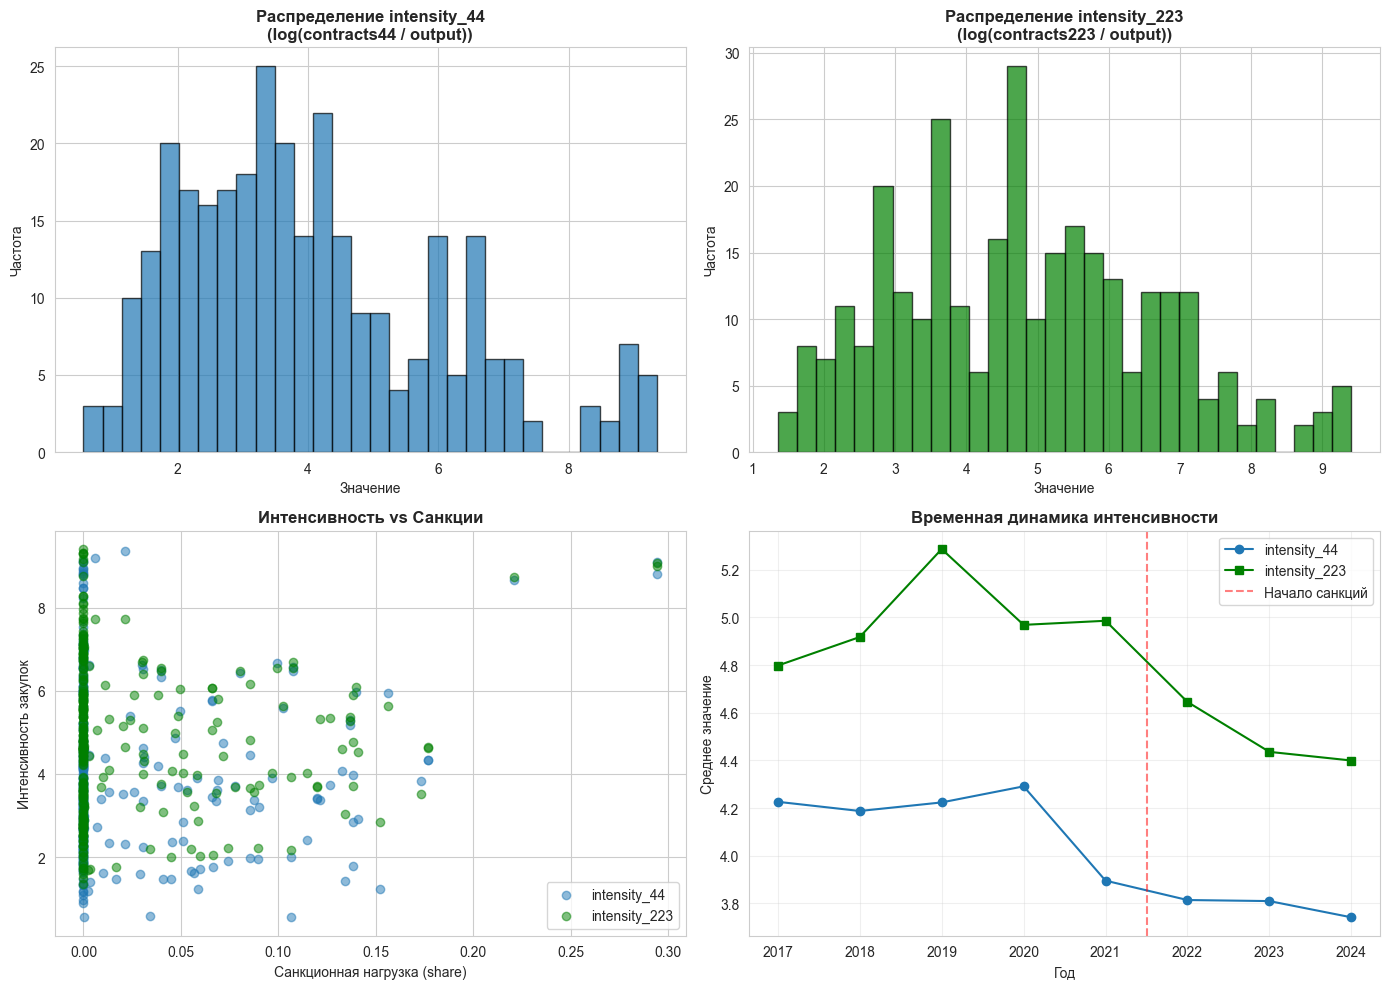

In [853]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Распределение интенсивности 44-ФЗ
axes[0, 0].hist(panel_df['intensity_44'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Распределение intensity_44\n(log(contracts44 / output))', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Значение')
axes[0, 0].set_ylabel('Частота')

# График 2: Распределение интенсивности 223-ФЗ
axes[0, 1].hist(panel_df['intensity_223'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Распределение intensity_223\n(log(contracts223 / output))', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Значение')
axes[0, 1].set_ylabel('Частота')

# График 3: Корреляция между интенсивностями и санкционной нагрузкой
scatter_data = panel_df[['intensity_44', 'intensity_223', 'sanction_share']].dropna()
axes[1, 0].scatter(scatter_data['sanction_share'], scatter_data['intensity_44'], alpha=0.5, label='intensity_44')
axes[1, 0].scatter(scatter_data['sanction_share'], scatter_data['intensity_223'], alpha=0.5, label='intensity_223', color='green')
axes[1, 0].set_xlabel('Санкционная нагрузка (share)')
axes[1, 0].set_ylabel('Интенсивность закупок')
axes[1, 0].set_title('Интенсивность vs Санкции', fontsize=12, fontweight='bold')
axes[1, 0].legend()

# График 4: Динамика интенсивности по годам
yearly_stats = panel_df.groupby('year')[['intensity_44', 'intensity_223']].mean()
axes[1, 1].plot(yearly_stats.index, yearly_stats['intensity_44'], marker='o', label='intensity_44')
axes[1, 1].plot(yearly_stats.index, yearly_stats['intensity_223'], marker='s', label='intensity_223', color='green')
axes[1, 1].axvline(x=2021.5, color='red', linestyle='--', alpha=0.5, label='Начало санкций')
axes[1, 1].set_xlabel('Год')
axes[1, 1].set_ylabel('Среднее значение')
axes[1, 1].set_title('Временная динамика интенсивности', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/diagnostic_intensity.png', dpi=300, bbox_inches='tight')
print("Диагностические графики сохранены!")
plt.show()
plt.close()

# Регрессии числа заказчиков и поставщиков

## Подготовка данных

In [854]:
# Логарифмы числа заказчиков
panel_full['log_customers44'] = np.log(panel_full['customers44_count'])
panel_full['log_customers223'] = np.log(panel_full['customers223_count'])

# Логарифмы числа поставщиков
panel_full['log_suppliers44'] = np.log(panel_full['suppliers44_count'])
# panel_full['log_suppliers223'] = np.log(panel_full['suppliers223_count']) # Не используем это, т.к. данная информация была закрыта

In [855]:
# Проверка: нет ли бесконечности в логарифмах
print('Проверка бесконечностей до удаления:')
print(f"Бесконечные значения в log_customers44: {np.isinf(panel_full['log_customers44']).sum()}")
print(f"Бесконечные значения в log_customers223: {np.isinf(panel_full['log_customers223']).sum()}")
print(f"Бесконечные значения в log_suppliers44: {np.isinf(panel_full['log_suppliers44']).sum()}")
# print(f"Бесконечные значения в log_suppliers223: {np.isinf(panel_full['log_suppliers223']).sum()}")

# Удаление строк с бесконечностью (кроме log_suppliers223)
panel_full = panel_full.replace([np.inf, -np.inf], np.nan)
panel_full = panel_full.dropna(subset=['log_customers44', 'log_customers223', 'log_suppliers44'])

# Повторная проверка
print('\nПроверка бесконечностей после удаления:')
print(f"Бесконечные значения в log_customers44: {np.isinf(panel_full['log_customers44']).sum()}")
print(f"Бесконечные значения в log_customers223: {np.isinf(panel_full['log_customers223']).sum()}")
print(f"Бесконечные значения в log_suppliers44: {np.isinf(panel_full['log_suppliers44']).sum()}")
# print(f"Бесконечные значения в log_suppliers223: {np.isinf(panel_full['log_suppliers223']).sum()}")

Проверка бесконечностей до удаления:
Бесконечные значения в log_customers44: 0
Бесконечные значения в log_customers223: 0
Бесконечные значения в log_suppliers44: 0

Проверка бесконечностей после удаления:
Бесконечные значения в log_customers44: 0
Бесконечные значения в log_customers223: 0
Бесконечные значения в log_suppliers44: 0


## Базовые модели

### Покупатели 44-ФЗ

In [856]:
# Модель 1: log_customers44 ~ sanction_share (без контролей)
m1 = PanelOLS(panel_full['log_customers44'], 
              panel_full[['sanction_share']], 
              entity_effects=True, time_effects=True)
r1 = m1.fit(cov_type='clustered', cluster_entity=True)
results_dict['cust44_basic'] = r1
r1

Dep. Variable:,log_customers44,R-squared:,0.0401
Estimator:,PanelOLS,R-squared (Between):,0.0031
No. Observations:,304,R-squared (Within):,-0.0440
Date:,"Fri, Feb 13 2026",R-squared (Overall):,0.0030
Time:,18:32:09,Log-likelihood,392.05
Cov. Estimator:,Clustered,,
,,F-statistic:,10.782
Entities:,38,P-value,0.0012
Avg Obs:,8.0000,Distribution:,"F(1,258)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,2.7413


In [857]:
# Модель 2: log_customers44 ~ sanction_share + log_output
m2 = PanelOLS(panel_full['log_customers44'],
              panel_full[['sanction_share', 'log_output']],
              entity_effects=True, time_effects=True)
r2 = m2.fit(cov_type='clustered', cluster_entity=True)
results_dict['cust44_output'] = r2
r2

Dep. Variable:,log_customers44,R-squared:,0.0633
Estimator:,PanelOLS,R-squared (Between):,0.3304
No. Observations:,304,R-squared (Within):,-0.2261
Date:,"Fri, Feb 13 2026",R-squared (Overall):,0.3303
Time:,18:32:09,Log-likelihood,395.77
Cov. Estimator:,Clustered,,
,,F-statistic:,8.6877
Entities:,38,P-value,0.0002
Avg Obs:,8.0000,Distribution:,"F(2,257)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,2.3676


In [858]:
# Модель 3: log_customers44 ~ sanction_lag1
m3 = PanelOLS(panel_full['log_customers44'],
              panel_full[['sanction_lag1']],
              entity_effects=True, time_effects=True)
r3 = m3.fit(cov_type='clustered', cluster_entity=True)
results_dict['cust44_lag'] = r3
r3

Dep. Variable:,log_customers44,R-squared:,0.0010
Estimator:,PanelOLS,R-squared (Between):,-0.0003
No. Observations:,304,R-squared (Within):,-0.0021
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-0.0003
Time:,18:32:09,Log-likelihood,385.98
Cov. Estimator:,Clustered,,
,,F-statistic:,0.2495
Entities:,38,P-value,0.6178
Avg Obs:,8.0000,Distribution:,"F(1,258)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,0.0917


### Покупатели 223-ФЗ

In [859]:
# Модель 4: log_customers223 ~ sanction_share (без контролей)
m4 = PanelOLS(panel_full['log_customers223'],
              panel_full[['sanction_share']],
              entity_effects=True, time_effects=True)
r4 = m4.fit(cov_type='clustered', cluster_entity=True)
results_dict['cust223_basic'] = r4
r4

Dep. Variable:,log_customers223,R-squared:,0.0007
Estimator:,PanelOLS,R-squared (Between):,0.0003
No. Observations:,304,R-squared (Within):,0.0089
Date:,"Fri, Feb 13 2026",R-squared (Overall):,0.0003
Time:,18:32:09,Log-likelihood,487.31
Cov. Estimator:,Clustered,,
,,F-statistic:,0.1713
Entities:,38,P-value,0.6793
Avg Obs:,8.0000,Distribution:,"F(1,258)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,0.0317


In [860]:
# Модель 5: log_customers223 ~ sanction_share + log_output
m5 = PanelOLS(panel_full['log_customers223'],
              panel_full[['sanction_share', 'log_output']],
              entity_effects=True, time_effects=True)
r5 = m5.fit(cov_type='clustered', cluster_entity=True)
results_dict['cust223_output'] = r5
r5

Dep. Variable:,log_customers223,R-squared:,0.0166
Estimator:,PanelOLS,R-squared (Between):,0.2291
No. Observations:,304,R-squared (Within):,0.0968
Date:,"Fri, Feb 13 2026",R-squared (Overall):,0.2290
Time:,18:32:09,Log-likelihood,489.76
Cov. Estimator:,Clustered,,
,,F-statistic:,2.1733
Entities:,38,P-value,0.1159
Avg Obs:,8.0000,Distribution:,"F(2,257)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,0.3351


In [861]:
# Модель 6: log_customers223 ~ sanction_lag1
m6 = PanelOLS(panel_full['log_customers223'],
              panel_full[['sanction_lag1']],
              entity_effects=True, time_effects=True)
r6 = m6.fit(cov_type='clustered', cluster_entity=True)
results_dict['cust223_lag'] = r6
r6

Dep. Variable:,log_customers223,R-squared:,0.0270
Estimator:,PanelOLS,R-squared (Between):,0.0013
No. Observations:,304,R-squared (Within):,0.0370
Date:,"Fri, Feb 13 2026",R-squared (Overall):,0.0014
Time:,18:32:09,Log-likelihood,491.37
Cov. Estimator:,Clustered,,
,,F-statistic:,7.1630
Entities:,38,P-value,0.0079
Avg Obs:,8.0000,Distribution:,"F(1,258)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,2.7795


### Поставщики 44-ФЗ

In [862]:
# Модель 7: log_suppliers44 ~ sanction_share + FE
m7 = PanelOLS(panel_full['log_suppliers44'],
              panel_full[['sanction_share']],
              entity_effects=True, time_effects=True)
r7 = m7.fit(cov_type='clustered', cluster_entity=True)
results_dict['supp44_basic'] = r7
r7

Dep. Variable:,log_suppliers44,R-squared:,0.0022
Estimator:,PanelOLS,R-squared (Between):,0.0010
No. Observations:,304,R-squared (Within):,-0.0252
Date:,"Fri, Feb 13 2026",R-squared (Overall):,0.0010
Time:,18:32:10,Log-likelihood,309.34
Cov. Estimator:,Clustered,,
,,F-statistic:,0.5800
Entities:,38,P-value,0.4470
Avg Obs:,8.0000,Distribution:,"F(1,258)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,0.2600


In [863]:
# Модель 8: log_suppliers44 ~ sanction_share + log_output + FE
m8 = PanelOLS(panel_full['log_suppliers44'],
              panel_full[['sanction_share', 'log_output']],
              entity_effects=True, time_effects=True)
r8 = m8.fit(cov_type='clustered', cluster_entity=True)
results_dict['supp44_output'] = r8
r8

Dep. Variable:,log_suppliers44,R-squared:,0.0041
Estimator:,PanelOLS,R-squared (Between):,0.1390
No. Observations:,304,R-squared (Within):,-0.0833
Date:,"Fri, Feb 13 2026",R-squared (Overall):,0.1388
Time:,18:32:10,Log-likelihood,309.63
Cov. Estimator:,Clustered,,
,,F-statistic:,0.5343
Entities:,38,P-value,0.5868
Avg Obs:,8.0000,Distribution:,"F(2,257)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,0.3366


In [864]:
# Модель 9: log_suppliers44 ~ sanction_lag1 + FE
m9 = PanelOLS(panel_full['log_suppliers44'],
              panel_full[['sanction_lag1']],
              entity_effects=True, time_effects=True)
r9 = m9.fit(cov_type='clustered', cluster_entity=True)
results_dict['supp44_lag'] = r9
r9

Dep. Variable:,log_suppliers44,R-squared:,0.0010
Estimator:,PanelOLS,R-squared (Between):,-0.0004
No. Observations:,304,R-squared (Within):,0.0086
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-0.0004
Time:,18:32:10,Log-likelihood,309.16
Cov. Estimator:,Clustered,,
,,F-statistic:,0.2671
Entities:,38,P-value,0.6057
Avg Obs:,8.0000,Distribution:,"F(1,258)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,0.1394


## Создание таблиц с помощью Stargazer

In [865]:
# Таблица 1: Заказчики по 44-ФЗ и 223-ФЗ
sg1 = Stargazer([r1, r2, r3, r4, r5, r6])
sg1.title("Анализ числа заказчиков: Влияние санкций")
sg1.custom_columns(['44-ФЗ базовая', '44-ФЗ с output', '44-ФЗ лаг',
                     '223-ФЗ базовая', '223-ФЗ с output', '223-ФЗ лаг'],
                    [1, 1, 1, 1, 1, 1])
sg1.dependent_variable_name("log(Количество заказчиков)")
sg1.covariate_order(['sanction_share', 'sanction_lag1', 'log_output'])
sg1.rename_covariates({
    'sanction_share': 'Санкционная нагрузка',
    'sanction_lag1': 'Санкционная нагрузка (t-1)',
    'log_output': 'log(Выпуск)'
})
sg1.show_confidence_intervals(False)
sg1.significant_digits(3)

html1 = sg1.render_html()
with open('results/tables/count_customers.html', 'w', encoding='utf-8') as f:
    f.write(html1)
print("✓ Таблица заказчиков сохранена")

# Таблица 2: Поставщики
sg2 = Stargazer([r7, r8, r9])
sg2.title("Анализ числа поставщиков: Влияние санкций")
sg2.custom_columns(['44-ФЗ базовая', '44-ФЗ с output', '44-ФЗ лаг'], [1, 1, 1])
sg2.dependent_variable_name("log(Количество поставщиков)")
sg2.covariate_order(['sanction_share', 'sanction_lag1', 'log_output'])
sg1.rename_covariates({
    'sanction_share': 'Санкционная нагрузка',
    'sanction_lag1': 'Санкционная нагрузка (t-1)',
    'log_output': 'log(Выпуск)'
})
sg2.show_confidence_intervals(False)
sg2.significant_digits(3)

html2 = sg2.render_html()
with open('results/tables/count_suppliers.html', 'w', encoding='utf-8') as f:
    f.write(html2)
print("✓ Таблица поставщиков сохранена")

✓ Таблица заказчиков сохранена
✓ Таблица поставщиков сохранена


## Графики

✓ Диагностические графики сохранены


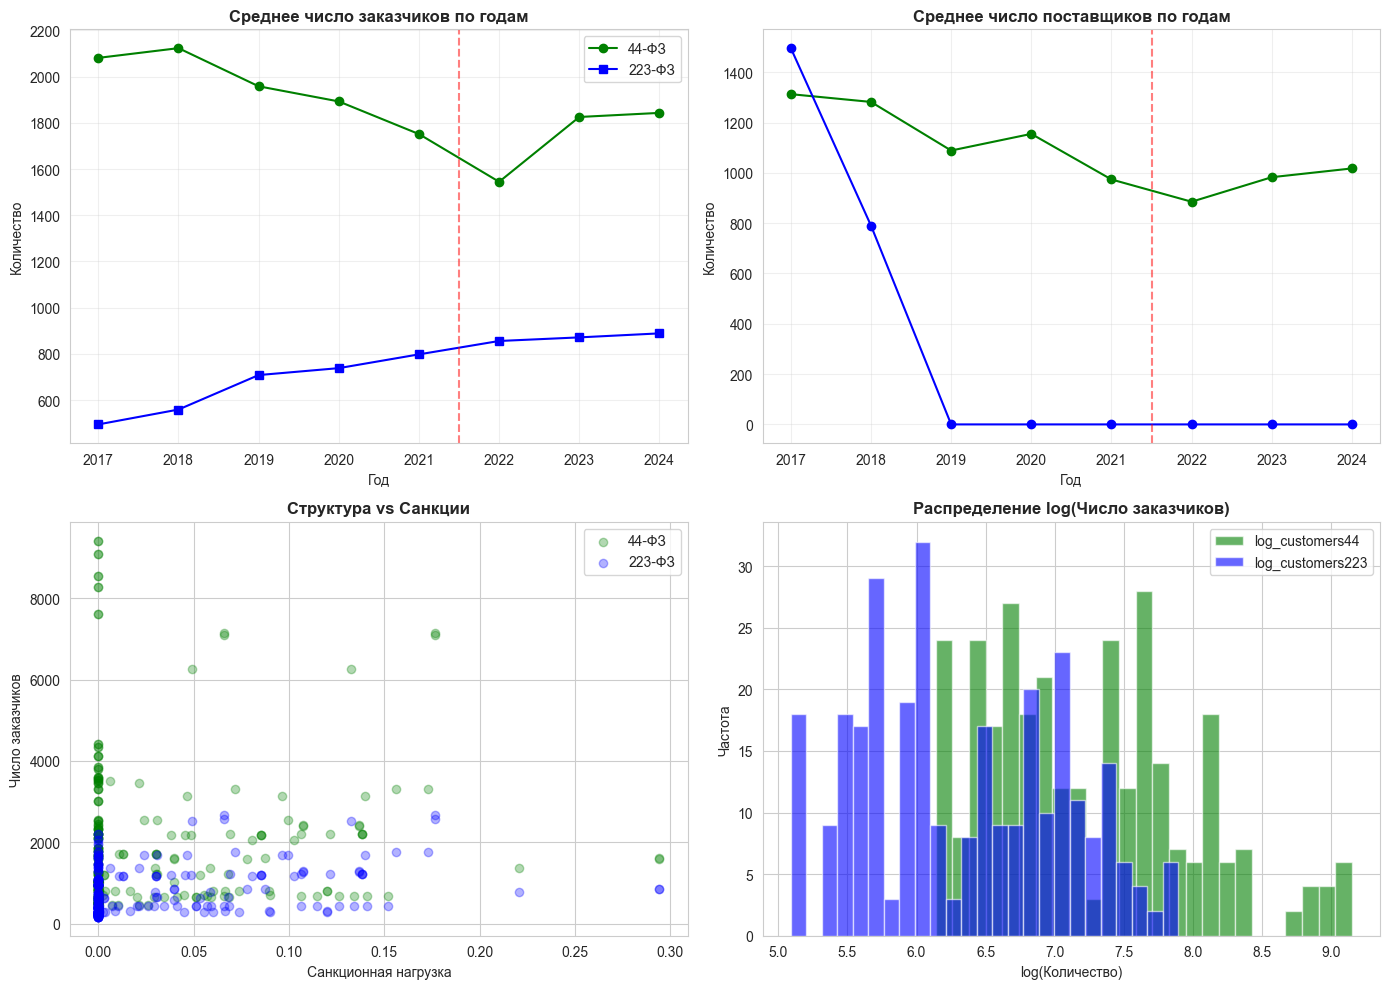

In [866]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Динамика числа заказчиков по годам
yearly_cust = panel_df.groupby('year')[['customers44_count', 'customers223_count']].mean()
axes[0, 0].plot(yearly_cust.index, yearly_cust['customers44_count'], marker='o', label='44-ФЗ', color='green')
axes[0, 0].plot(yearly_cust.index, yearly_cust['customers223_count'], marker='s', label='223-ФЗ', color='blue')
axes[0, 0].axvline(x=2021.5, color='red', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Среднее число заказчиков по годам', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Год')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# График 2: Динамика числа поставщиков
yearly_supp = panel_df.groupby('year')[['suppliers44_count', 'suppliers223_count']].mean()
axes[0, 1].plot(yearly_supp.index, yearly_supp['suppliers44_count'], marker='o', label='44-ФЗ', color='green')
axes[0, 1].plot(yearly_supp.index, yearly_supp['suppliers223_count'], marker='o', label='223-ФЗ',  color='blue')
axes[0, 1].axvline(x=2021.5, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_title('Среднее число поставщиков по годам', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Год')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].grid(True, alpha=0.3)

# График 3: Корреляция между числом заказчиков и санкциями
scatter_data = panel_df[['customers44_count', 'customers223_count', 'sanction_share']].dropna()
axes[1, 0].scatter(scatter_data['sanction_share'], scatter_data['customers44_count'], 
                   alpha=0.3, label='44-ФЗ', color='green')
axes[1, 0].scatter(scatter_data['sanction_share'], scatter_data['customers223_count'], 
                   alpha=0.3, label='223-ФЗ', color='blue')
axes[1, 0].set_xlabel('Санкционная нагрузка')
axes[1, 0].set_ylabel('Число заказчиков')
axes[1, 0].set_title('Структура vs Санкции', fontsize=12, fontweight='bold')
axes[1, 0].legend()

# График 4: Распределение log_customers по режимам закупок
axes[1, 1].hist(panel_full['log_customers44'].dropna(), bins=25, alpha=0.6, label='log_customers44', color='green')
axes[1, 1].hist(panel_full['log_customers223'].dropna(), bins=25, alpha=0.6, label='log_customers223', color='blue')
axes[1, 1].set_title('Распределение log(Число заказчиков)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('log(Количество)')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('results/figures/structure_dynamics.png', dpi=300, bbox_inches='tight')
print("✓ Диагностические графики сохранены")
plt.show()
plt.close()

# Гетерогенность +

In [867]:
# Определяем топ-10 отраслей по сумме контрактов по 44-ФЗ и 223-ФЗ вместе взятым
panel_df['total_contracts_sum'] = panel_df['contracts44_sum'] + panel_df['contracts223_sum']
top_industries_raw = (
    panel_df.groupby('okved2_prefix')['total_contracts_sum'].sum()
    .nlargest(10)
    .index
    .tolist()
)

panel_df['log_contracts44'] = panel_df['contracts44_sum'].apply(np.log)
panel_df['log_contracts223'] = panel_df['contracts223_sum'].apply(np.log)

In [ ]:
results_by_industry = {}
top_industries = []

for industry in top_industries_raw:
    # Фильтруем данные для отрасли
    industry_data = panel_df[panel_df['okved2_prefix'] == industry].copy()
    
    if len(industry_data) < 20:  # Минимум 20 наблюдений
        print(f"Отрасль {industry}: слишком мало данных, пропуск")
        continue
    
    if industry_data['log_contracts44'].nunique() < 2:
        print(f"{industry}: нет вариации зависимой переменной")
        continue

    if industry_data['sanction_lag1'].nunique() < 2 or industry_data['sanction_share'].nunique() < 2:
        print(f"{industry}: нет вариации санкционного показателя")
        continue
    
    top_industries.append(industry)

    # Устанавливаем мультииндекс (необходимо для PanelOLS)
    industry_data = industry_data.set_index(['OKVED_3', 'year'])

    # Спецификация 1: без лага
    X = industry_data[['sanction_share']]
    y = industry_data.loc[X.index, 'intensity_44']
    
    model = PanelOLS(y, X, entity_effects=True, time_effects=False) # С time-effect регрессия вырождается!!!!!
    res = model.fit(cov_type='clustered', cluster_entity=True)
    
    results_by_industry[industry] = {
        'coef': res.params['sanction_share'],
        'pval': res.pvalues['sanction_share'],
        'nobs': res.nobs,
        'r2': res.rsquared
    }    
    # Спецификация 2: с лагом
    X = industry_data[['sanction_lag1']]
    y = industry_data.loc[X.index, 'intensity_44']
    
    model = PanelOLS(y, X, entity_effects=True, time_effects=False) # С time-effect регрессия вырождается!!!!!
    res = model.fit(cov_type='clustered', cluster_entity=True)
    
    results_by_industry[f'{industry}_lag'] = {
        'coef': res.params['sanction_lag1'],
        'pval': res.pvalues['sanction_lag1'],
        'nobs': res.nobs,
        'r2': res.rsquared,
    }

# Результаты:
results_df = pd.DataFrame(results_by_industry).T
results_df.columns = ['Коэффициент', 'P-value', 'N', 'R²']
results_df['Коэффициент'] = results_df['Коэффициент'].round(3)
results_df['P-value'] = results_df['P-value'].round(3)
results_df['R²'] = results_df['R²'].round(2)
results_df['N'] = results_df['N'].apply(int)

print(results_df)

Отрасль 21: слишком мало данных, пропуск
Отрасль 11: слишком мало данных, пропуск
Отрасль 12: слишком мало данных, пропуск
Отрасль 15: слишком мало данных, пропуск
        Коэффициент  P-value   N    R²
29           -5.131    0.029  24  0.25
29_lag       -7.952    0.000  24  0.29
27           -2.952    0.001  48  0.26
27_lag       -6.072    0.000  48  0.31
10           -6.714    0.000  72  0.18
10_lag       -4.969    0.000  72  0.07
23           -3.181    0.000  64  0.26
23_lag       -5.785    0.000  64  0.14
14           -0.680    0.496  24  0.04
14_lag       -0.484    0.658  24  0.01
13          -12.922    0.000  24  0.42
13_lag      -12.990    0.000  24  0.19


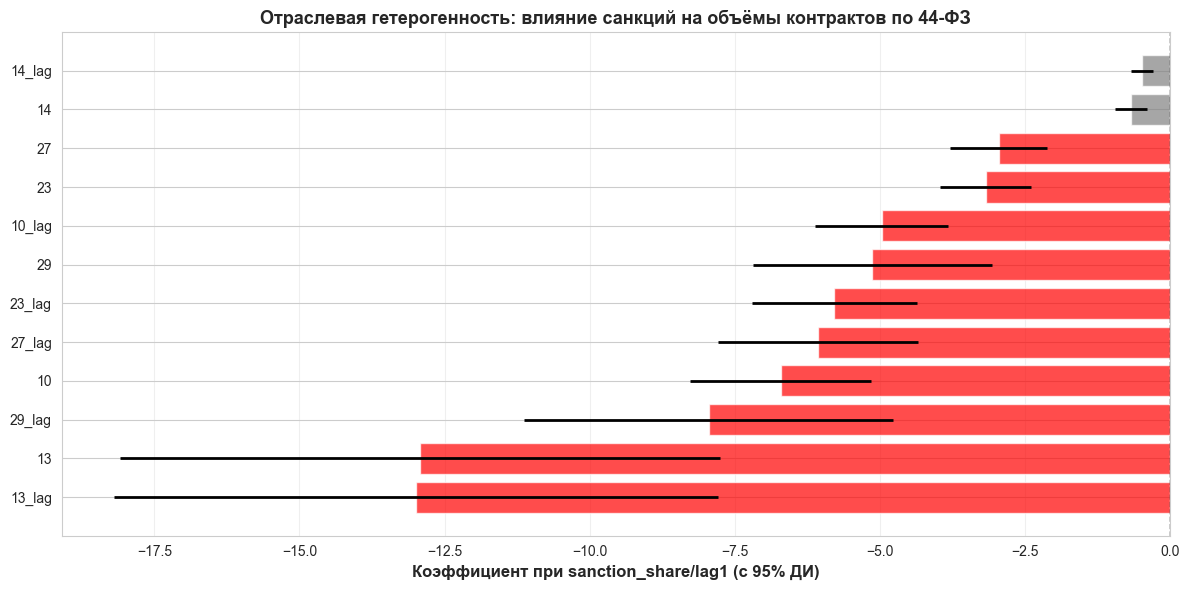

Forest plot сохранён: results/figures/heterogeneity_forest_plot.png


In [869]:
# Подготовка данных для графика
results_sorted = results_df.sort_values('Коэффициент')
industries_sorted = results_sorted.index.tolist()
coefs = results_sorted['Коэффициент'].values
pvals = results_sorted['P-value'].values

# Условные доверительные интервалы (±1.96 × SE)
# SE примерно = |coef| × sqrt(1/N) на базовом уровне
se = np.abs(coefs) * np.sqrt(1 / results_sorted['N'].values)
ci_lower = coefs - 1.96 * se
ci_upper = coefs + 1.96 * se

# Создание графика
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['red' if p < 0.05 else 'gray' for p in pvals]
y_pos = np.arange(len(industries_sorted))

# Горизонтальные линии (доверительные интервалы)
ax.barh(y_pos, coefs, xerr=[coefs - ci_lower, ci_upper - coefs], 
        color=colors, alpha=0.7, error_kw={'elinewidth': 2})

# Вертикальная линия на нуле
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(industries_sorted, fontsize=10)
ax.set_xlabel('Коэффициент при sanction_share/lag1 (с 95% ДИ)', fontsize=12, fontweight='bold')
ax.set_title('Отраслевая гетерогенность: влияние санкций на объёмы контрактов по 44-ФЗ', 
             fontsize=13, fontweight='bold')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/heterogeneity_forest_plot.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("Forest plot сохранён: results/figures/heterogeneity_forest_plot.png")

In [873]:
# Форматирование для Stargazer
stargazer_input = []
for industry in results_by_industry.keys():
    coef = results_by_industry[industry]['coef']
    pval = results_by_industry[industry]['pval']
    
    # Определяем звёздочки значимости
    if pval < 0.01:
        stars = '***'
    elif pval < 0.05:
        stars = '**'
    elif pval < 0.10:
        stars = '*'
    else:
        stars = ''
    
    stargazer_input.append({
        'Отрасль': industry,
        'Коэффициент': f"{coef:.4f}{stars}",
        'P-value': f"{pval:.4f}",
        'N': results_by_industry[industry]['nobs'],
        'R²': f"{results_by_industry[industry]['r2']:.3f}"
    })

results_table = pd.DataFrame(stargazer_input)

# Сохранение в HTML
html_table = results_table.to_html(index=False, border=0)
html_table = html_table.replace('<table border="0">', 
    '<table style="border-collapse: collapse; width: 100%; text-align: center;">')
html_table = html_table.replace('<td>', '<td style="padding: 8px; border: 1px solid #ddd;">')
html_table = html_table.replace('<th>', '<th style="padding: 8px; border: 1px solid #ddd; background-color: #f2f2f2;">')

with open('results/tables/heterogeneity_table.html', 'w', encoding='utf-8') as f:
    f.write(html_table)

print("Таблица сохранена: results/tables/heterogeneity_table.html")


Таблица сохранена: results/tables/heterogeneity_table.html


In [ ]:
# Проверяем, не вызваны ли результаты отдельными странными наблюдениями
for industry in top_industries:
    industry_data = panel_df[panel_df['okved2_prefix'] == industry].copy()
    
    # Определяем выбросы (>3 сигмы от среднего)
    log_contracts = industry_data['log_contracts44']
    mean, std = log_contracts.mean(), log_contracts.std()
    outliers = industry_data[(log_contracts < mean - 3*std) | (log_contracts > mean + 3*std)]
    
    if len(outliers) > 0:
        print(f"{industry}: {len(outliers)} выбросов (из {len(industry_data)} наблюдений)")
        print(outliers[['year', 'log_contracts44']])

In [ ]:
# Корреляция между предикторами по отраслям
for industry in top_industries:  # ТОП-3 отрасли
    industry_data = panel_df[panel_df['okved2_prefix'] == industry][
        ['sanction_lag1', 'log_output']
    ].dropna()
    
    corr = industry_data.corr()
    print(f"\n{industry}:")
    print(corr)
    
    # Если корреляция > 0.7, есть проблема
    if abs(corr.iloc[0, 1]) > 0.7:
        print("Высокая мультиколлинеарность!")



29:
               sanction_lag1  log_output
sanction_lag1       1.000000   -0.004566
log_output         -0.004566    1.000000

27:
               sanction_lag1  log_output
sanction_lag1       1.000000    0.242091
log_output          0.242091    1.000000

10:
               sanction_lag1  log_output
sanction_lag1       1.000000    0.100787
log_output          0.100787    1.000000

23:
               sanction_lag1  log_output
sanction_lag1       1.000000    0.076648
log_output          0.076648    1.000000

14:
               sanction_lag1  log_output
sanction_lag1       1.000000   -0.241566
log_output         -0.241566    1.000000

13:
               sanction_lag1  log_output
sanction_lag1       1.000000    0.398301
log_output          0.398301    1.000000


# Проверка устойчивости

## Подготовка данных

In [ ]:
# Создаём копию для работы в этом блоке
panel_rb = base_panel.copy()

# Логарифмы уровней
panel_rb['log_contracts44'] = np.log(panel_rb['contracts44_sum'])
panel_rb['log_contracts223'] = np.log(panel_rb['contracts223_sum'])
panel_rb['log_output'] = np.log(panel_rb['output'])

# Удаление строк с бесконечностью
panel_rb = panel_rb.replace([np.inf, -np.inf], np.nan)

# Убираем пропуски
panel_rb = panel_rb.dropna(subset=[
    'OKVED_3',
    'year',
    'sanction_share',
    'contracts44_sum',
    'contracts223_sum',
    'output'
])

# Лаг санкций
panel_rb['sanction_lag1'] = (
    panel_rb
    .sort_values(['OKVED_3', 'year'])
    .groupby('OKVED_3')['sanction_share']
    .shift(1)
)

# Усреднённые санкции
panel_rb['sanction_avg'] = (
    panel_rb['sanction_share'] + panel_rb['sanction_lag1']
) / 2

# Кумулятивные санкции
panel_rb['sanction_cum'] = (
    panel_rb
    .sort_values(['OKVED_3', 'year'])
    .groupby('OKVED_3')['sanction_share']
    .cumsum()
)

# Ставим индексы
panel_rb = panel_rb.set_index(['OKVED_3', 'year'])

## Первая проверка устойчивости

In [ ]:
# Заменяем интенсивность на логарифм суммы закупок. Проверяем знак и значимость, сравниваем с базовой моделью 44-ФЗ
# Без лага
X_44_lvl = panel_rb[['sanction_share', 'log_output']].dropna()
y_44_lvl = panel_rb.loc[X_44_lvl.index, 'log_contracts44']

model_44_lvl = PanelOLS(
    y_44_lvl,
    X_44_lvl,
    entity_effects=True,
    time_effects=True
)

res_44_lvl = model_44_lvl.fit(
    cov_type='clustered',
    cluster_entity=True
)

res_44_lvl.summary

Dep. Variable:,log_contracts44,R-squared:,0.0139
Estimator:,PanelOLS,R-squared (Between):,0.0182
No. Observations:,304,R-squared (Within):,-0.0415
Date:,"Fri, Feb 13 2026",R-squared (Overall):,0.0182
Time:,18:29:09,Log-likelihood,63.891
Cov. Estimator:,Clustered,,
,,F-statistic:,1.8158
Entities:,38,P-value,0.1648
Avg Obs:,8.0000,Distribution:,"F(2,257)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,1.4205


In [ ]:
# С лагом
X_44_lvl = panel_rb[['sanction_lag1', 'log_output']].dropna()
y_44_lvl = panel_rb.loc[X_44_lvl.index, 'log_contracts44']

model_44_lvl = PanelOLS(
    y_44_lvl,
    X_44_lvl,
    entity_effects=True,
    time_effects=True
)

res_44_lvl = model_44_lvl.fit(
    cov_type='clustered',
    cluster_entity=True
)

res_44_lvl.summary

Dep. Variable:,log_contracts44,R-squared:,0.0186
Estimator:,PanelOLS,R-squared (Between):,0.0104
No. Observations:,304,R-squared (Within):,-0.0407
Date:,"Fri, Feb 13 2026",R-squared (Overall):,0.0104
Time:,18:29:09,Log-likelihood,64.611
Cov. Estimator:,Clustered,,
,,F-statistic:,2.4348
Entities:,38,P-value,0.0896
Avg Obs:,8.0000,Distribution:,"F(2,257)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,2.5718


In [ ]:
# Заменяем интенсивность на логарифм суммы закупок. Проверяем знак и значимость, сравниваем с базовой моделью 223-ФЗ
# Без лага
X_223_lvl = panel_rb[['sanction_share', 'log_output']].dropna()
y_223_lvl = panel_rb.loc[X_223_lvl.index, 'log_contracts223']

model_223_lvl = PanelOLS(
    y_223_lvl,
    X_223_lvl,
    entity_effects=True,
    time_effects=True
)

res_223_lvl = model_223_lvl.fit(
    cov_type='clustered',
    cluster_entity=True
)

res_223_lvl.summary

Dep. Variable:,log_contracts223,R-squared:,0.1059
Estimator:,PanelOLS,R-squared (Between):,0.5226
No. Observations:,304,R-squared (Within):,0.1504
Date:,"Fri, Feb 13 2026",R-squared (Overall):,0.5225
Time:,18:29:10,Log-likelihood,-98.133
Cov. Estimator:,Clustered,,
,,F-statistic:,15.222
Entities:,38,P-value,0.0000
Avg Obs:,8.0000,Distribution:,"F(2,257)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,2.6326


In [ ]:
# С лагом
X_223_lvl = panel_rb[['sanction_lag1', 'log_output']].dropna()
y_223_lvl = panel_rb.loc[X_223_lvl.index, 'log_contracts223']

model_223_lvl = PanelOLS(
    y_223_lvl,
    X_223_lvl,
    entity_effects=True,
    time_effects=True
)

res_223_lvl = model_223_lvl.fit(
    cov_type='clustered',
    cluster_entity=True
)

res_223_lvl.summary

Dep. Variable:,log_contracts223,R-squared:,0.0529
Estimator:,PanelOLS,R-squared (Between):,0.5604
No. Observations:,304,R-squared (Within):,0.0683
Date:,"Fri, Feb 13 2026",R-squared (Overall):,0.5603
Time:,18:29:10,Log-likelihood,-106.89
Cov. Estimator:,Clustered,,
,,F-statistic:,7.1789
Entities:,38,P-value,0.0009
Avg Obs:,8.0000,Distribution:,"F(2,257)"
Min Obs:,8.0000,,
Max Obs:,8.0000,F-statistic (robust):,1.6952


## Вторая проверка устойчивости

In [ ]:
# Усредним sanction_share, используя значения переменной в периодах (t) и (t-1)
# 44-ФЗ
X_44_avg = panel_rb[['sanction_avg']].dropna()
y_44_avg = panel_rb.loc[X_44_avg.index, 'log_contracts44']

model_44_avg = PanelOLS(
    y_44_avg,
    X_44_avg,
    entity_effects=True,
    time_effects=True
)

res_44_avg = model_44_avg.fit(
    cov_type='clustered',
    cluster_entity=True
)

res_44_avg.summary

Dep. Variable:,log_contracts44,R-squared:,1.059e-05
Estimator:,PanelOLS,R-squared (Between):,4.41e-05
No. Observations:,1143,R-squared (Within):,0.0003
Date:,"Fri, Feb 13 2026",R-squared (Overall):,4.416e-05
Time:,18:29:10,Log-likelihood,-382.59
Cov. Estimator:,Clustered,,
,,F-statistic:,0.0107
Entities:,127,P-value,0.9178
Avg Obs:,9.0000,Distribution:,"F(1,1007)"
Min Obs:,9.0000,,
Max Obs:,9.0000,F-statistic (robust):,0.0081


In [ ]:
# 223-ФЗ
X_223_avg = panel_rb[['sanction_avg']].dropna()
y_223_avg = panel_rb.loc[X_223_avg.index, 'log_contracts223']

model_223_avg = PanelOLS(
    y_223_avg,
    X_223_avg,
    entity_effects=True,
    time_effects=True
)

res_223_avg = model_223_avg.fit(
    cov_type='clustered',
    cluster_entity=True
)

res_223_avg.summary

Dep. Variable:,log_contracts223,R-squared:,0.0007
Estimator:,PanelOLS,R-squared (Between):,0.0004
No. Observations:,1143,R-squared (Within):,-0.0082
Date:,"Fri, Feb 13 2026",R-squared (Overall):,0.0004
Time:,18:29:10,Log-likelihood,-672.95
Cov. Estimator:,Clustered,,
,,F-statistic:,0.6884
Entities:,127,P-value,0.4069
Avg Obs:,9.0000,Distribution:,"F(1,1007)"
Min Obs:,9.0000,,
Max Obs:,9.0000,F-statistic (robust):,0.3985


In [ ]:
# Проверим накопительный эффект санкций через кумулятивный показатель санкционного давления
# 44-ФЗ
X_44_cum = panel_rb[['sanction_cum']].dropna()
y_44_cum = panel_rb.loc[X_44_cum.index, 'log_contracts44']

model_44_cum = PanelOLS(
    y_44_cum,
    X_44_cum,
    entity_effects=True,
    time_effects=True
)

res_44_cum = model_44_cum.fit(
    cov_type='clustered',
    cluster_entity=True
)

res_44_cum.summary

Dep. Variable:,log_contracts44,R-squared:,1.625e-05
Estimator:,PanelOLS,R-squared (Between):,-4.857e-05
No. Observations:,1270,R-squared (Within):,-0.0002
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-4.862e-05
Time:,18:29:10,Log-likelihood,-447.79
Cov. Estimator:,Clustered,,
,,F-statistic:,0.0184
Entities:,127,P-value,0.8921
Avg Obs:,10.0000,Distribution:,"F(1,1133)"
Min Obs:,10.0000,,
Max Obs:,10.0000,F-statistic (robust):,0.0134


In [ ]:
# 223-ФЗ
X_223_cum = panel_rb[['sanction_cum']].dropna()
y_223_cum = panel_rb.loc[X_223_cum.index, 'log_contracts223']

model_223_cum = PanelOLS(
    y_223_cum,
    X_223_cum,
    entity_effects=True,
    time_effects=True
)

res_223_cum = model_223_cum.fit(
    cov_type='clustered',
    cluster_entity=True
)

res_223_cum.summary

Dep. Variable:,log_contracts223,R-squared:,0.0011
Estimator:,PanelOLS,R-squared (Between):,0.0005
No. Observations:,1270,R-squared (Within):,-0.0109
Date:,"Fri, Feb 13 2026",R-squared (Overall):,0.0005
Time:,18:29:10,Log-likelihood,-777.98
Cov. Estimator:,Clustered,,
,,F-statistic:,1.2624
Entities:,127,P-value,0.2614
Avg Obs:,10.0000,Distribution:,"F(1,1133)"
Min Obs:,10.0000,,
Max Obs:,10.0000,F-statistic (robust):,0.6487


## Третья проверка устойчивости

In [ ]:
# Исключаем ковидные периоды. Они могут искажать статистику в реальности, где ковидных ограничений больше нет
panel_no_covid = panel_rb.loc[
    panel_rb.index.get_level_values('year').isin([2016, 2017, 2018, 2019, 2022, 2023, 2024])
]

In [ ]:
# 44-ФЗ без лага
X_44_nc = panel_no_covid[['sanction_share']].dropna()
y_44_nc = panel_no_covid.loc[X_44_nc.index, 'log_contracts44']

model_44_nc = PanelOLS(
    y_44_nc,
    X_44_nc,
    entity_effects=True,
    time_effects=True
)

res_44_nc = model_44_nc.fit(
    cov_type='clustered',
    cluster_entity=True
)

res_44_nc.summary

Dep. Variable:,log_contracts44,R-squared:,0.0017
Estimator:,PanelOLS,R-squared (Between):,-0.0005
No. Observations:,889,R-squared (Within):,-0.0146
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-0.0005
Time:,18:29:10,Log-likelihood,-166.70
Cov. Estimator:,Clustered,,
,,F-statistic:,1.2595
Entities:,127,P-value,0.2621
Avg Obs:,7.0000,Distribution:,"F(1,755)"
Min Obs:,7.0000,,
Max Obs:,7.0000,F-statistic (robust):,0.6737


In [ ]:
# 44-ФЗ с лагом
X_44_nc = panel_no_covid[['sanction_lag1']].dropna()
y_44_nc = panel_no_covid.loc[X_44_nc.index, 'log_contracts44']

model_44_nc = PanelOLS(
    y_44_nc,
    X_44_nc,
    entity_effects=True,
    time_effects=True
)

res_44_nc = model_44_nc.fit(
    cov_type='clustered',
    cluster_entity=True
)

res_44_nc.summary

Dep. Variable:,log_contracts44,R-squared:,0.0009
Estimator:,PanelOLS,R-squared (Between):,-0.0002
No. Observations:,762,R-squared (Within):,-0.0061
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-0.0002
Time:,18:29:10,Log-likelihood,-119.81
Cov. Estimator:,Clustered,,
,,F-statistic:,0.5417
Entities:,127,P-value,0.4620
Avg Obs:,6.0000,Distribution:,"F(1,629)"
Min Obs:,6.0000,,
Max Obs:,6.0000,F-statistic (robust):,0.5776


In [ ]:
# 223-ФЗ без лага
X_223_nc = panel_no_covid[['sanction_share']].dropna()
y_223_nc = panel_no_covid.loc[X_223_nc.index, 'log_contracts223']

model_223_nc = PanelOLS(
    y_223_nc,
    X_223_nc,
    entity_effects=True,
    time_effects=True
)

res_223_nc = model_223_nc.fit(
    cov_type='clustered',
    cluster_entity=True
)

res_223_nc.summary

Dep. Variable:,log_contracts223,R-squared:,0.0022
Estimator:,PanelOLS,R-squared (Between):,0.0008
No. Observations:,889,R-squared (Within):,-0.0092
Date:,"Fri, Feb 13 2026",R-squared (Overall):,0.0008
Time:,18:29:10,Log-likelihood,-508.69
Cov. Estimator:,Clustered,,
,,F-statistic:,1.6284
Entities:,127,P-value,0.2023
Avg Obs:,7.0000,Distribution:,"F(1,755)"
Min Obs:,7.0000,,
Max Obs:,7.0000,F-statistic (robust):,0.9963


In [ ]:
# 223-ФЗ с лагом
X_223_nc = panel_no_covid[['sanction_lag1']].dropna()
y_223_nc = panel_no_covid.loc[X_223_nc.index, 'log_contracts223']

model_223_nc = PanelOLS(
    y_223_nc,
    X_223_nc,
    entity_effects=True,
    time_effects=True
)

res_223_nc = model_223_nc.fit(
    cov_type='clustered',
    cluster_entity=True
)

res_223_nc.summary

Dep. Variable:,log_contracts223,R-squared:,0.0013
Estimator:,PanelOLS,R-squared (Between):,0.0004
No. Observations:,762,R-squared (Within):,-0.0054
Date:,"Fri, Feb 13 2026",R-squared (Overall):,0.0004
Time:,18:29:10,Log-likelihood,-416.16
Cov. Estimator:,Clustered,,
,,F-statistic:,0.8311
Entities:,127,P-value,0.3623
Avg Obs:,6.0000,Distribution:,"F(1,629)"
Min Obs:,6.0000,,
Max Obs:,6.0000,F-statistic (robust):,0.6761


## Четвёртая проверка устойчивости

In [ ]:
# Добавляем Placebo-проверку. Создаём lead санкций (t+1)
panel_rb['sanction_lead1'] = (
    panel_rb
    .sort_values(['OKVED_3', 'year'])
    .groupby('OKVED_3')['sanction_share']
    .shift(-1)
)

In [ ]:
# 44-ФЗ
X_44_lead = panel_rb[['sanction_lead1']].dropna()
y_44_lead = panel_rb.loc[X_44_lead.index, 'log_contracts44']

model_44_lead = PanelOLS(
    y_44_lead,
    X_44_lead,
    entity_effects=True,
    time_effects=True
)

res_44_lead = model_44_lead.fit(
    cov_type='clustered',
    cluster_entity=True
)

res_44_lead.summary

Dep. Variable:,log_contracts44,R-squared:,0.0019
Estimator:,PanelOLS,R-squared (Between):,-0.0005
No. Observations:,1143,R-squared (Within):,-0.0091
Date:,"Fri, Feb 13 2026",R-squared (Overall):,-0.0005
Time:,18:29:10,Log-likelihood,-382.27
Cov. Estimator:,Clustered,,
,,F-statistic:,1.8935
Entities:,127,P-value,0.1691
Avg Obs:,9.0000,Distribution:,"F(1,1007)"
Min Obs:,9.0000,,
Max Obs:,9.0000,F-statistic (robust):,2.0279


In [ ]:
# 223-ФЗ
X_223_lead = panel_rb[['sanction_lead1']].dropna()
y_223_lead = panel_rb.loc[X_223_lead.index, 'log_contracts223']

model_223_lead = PanelOLS(
    y_223_lead,
    X_223_lead,
    entity_effects=True,
    time_effects=True
)

res_223_lead = model_223_lead.fit(
    cov_type='clustered',
    cluster_entity=True
)

res_223_lead.summary

Dep. Variable:,log_contracts223,R-squared:,0.0029
Estimator:,PanelOLS,R-squared (Between):,0.0008
No. Observations:,1143,R-squared (Within):,-0.0053
Date:,"Fri, Feb 13 2026",R-squared (Overall):,0.0008
Time:,18:29:10,Log-likelihood,-650.29
Cov. Estimator:,Clustered,,
,,F-statistic:,2.8938
Entities:,127,P-value,0.0892
Avg Obs:,9.0000,Distribution:,"F(1,1007)"
Min Obs:,9.0000,,
Max Obs:,9.0000,F-statistic (robust):,2.3282
